# Benchmark: 3D Folding Correction

Demonstrates the `iterative_3d` solver correcting negative Jacobian
determinants in 3D deformation fields.  Includes:

- Synthetic random DVFs at varying sizes (5Ã—5Ã—5, 6Ã—8Ã—8, 8Ã—8Ã—8)
- Real-data 3D crops from Elastix registrations
- 3D Jacobian determinant visualisations (scatter, voxel highlighting, deformation grid)
- Per-slice Jdet heatmaps (before vs after)
- Scaling metrics (runtime, L2 error, convergence)

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..")))
import os
import time
import numpy as np
import matplotlib.pyplot as plt

from dvfopt import (
    iterative_3d,
    jacobian_det3D,
    generate_random_dvf_3d,
    scale_dvf_3d,
)
from dvfopt.viz import (
    plot_jdet_slices,
    plot_jdet_3d_before_after,
    plot_neg_voxels_before_after,
    plot_grid_before_after_3d,
)
from benchmark_utils import run_correction_3d
from benchmark_utils import get_output_dir, save_figure, save_results_csv, save_summary_json, log_run_header, log_run_footer, results_to_rows, show_and_save, reset_figure_counter


In [ ]:
METHOD = "slsqp"
NOTEBOOK_NAME = "3d-correction"
OUTPUT_DIR = get_output_dir(METHOD, NOTEBOOK_NAME, base="../../output")
reset_figure_counter()
summary = log_run_header(METHOD, NOTEBOOK_NAME, OUTPUT_DIR)


## Configuration

In [2]:
# Synthetic test sizes (D, H, W)
SYNTHETIC_SIZES = [
    (5, 5, 5),
    (4, 6, 5),    # non-cubic
    (6, 8, 8),
    (8, 8, 8),
]

# Base coarse DVF for upscaling
BASE_SHAPE = (3, 3, 3, 3)
MAX_MAGNITUDE = 4.0
SEED = 42

# Full-volume downsample factor (applied to preview and correction run)
DOWNSAMPLE_FACTOR = 1 / 4


---
## Generate synthetic test fields

In [3]:
base_dvf = generate_random_dvf_3d(BASE_SHAPE, MAX_MAGNITUDE, SEED)

test_fields = {}
for size in SYNTHETIC_SIZES:
    dvf = scale_dvf_3d(base_dvf, size)
    jac = jacobian_det3D(dvf)
    n_neg = int((jac <= 0).sum())
    total = size[0] * size[1] * size[2]
    label = f"{size[0]}x{size[1]}x{size[2]}"
    test_fields[label] = dvf
    print(f"  {label:>10s}  voxels={total:>5d}  neg={n_neg:>4d}  "
          f"min_jdet={jac.min():+.4f}")

       5x5x5  voxels=  125  neg=  64  min_jdet=-56.0061
       4x6x5  voxels=  120  neg=  59  min_jdet=-57.0625
       6x8x8  voxels=  384  neg= 177  min_jdet=-44.9554
       8x8x8  voxels=  512  neg= 244  min_jdet=-43.2706


## Run corrections

In [4]:
results = {}

print(f"{'Case':>12s}  {'Time (s)':>10s}  {'Neg init':>10s}  {'Neg final':>10s}  "
      f"{'Min Jdet':>10s}  {'L2 Error':>10s}")
print("-" * 72)

for label, dvf in test_fields.items():
    results[label] = run_correction_3d(dvf, iterative_3d)
    r = results[label]
    status = "OK" if r["n_neg_final"] == 0 else "FAIL"
    print(f"{label:>12s}  {r['time']:>10.2f}  {r['n_neg_init']:>10d}  "
          f"{r['n_neg_final']:>10d}  {r['min_jdet']:>+10.6f}  "
          f"{r['l2_err']:>10.4f}  [{status}]")

        Case    Time (s)    Neg init   Neg final    Min Jdet    L2 Error
------------------------------------------------------------------------
       5x5x5        0.43          64           0   +0.010000      5.7205  [OK]
       4x6x5        0.33          59           0   +0.010000      4.7900  [OK]
       6x8x8       12.47         177           0   +0.010000      8.7883  [OK]
       8x8x8      132.61         244           0   +0.010000     10.3818  [OK]


## Load real-data crops (if available)

In [5]:
real_cases = [
    ("../../../data/test_cases_3d/slice350_5x10x10.npy", "Real 5x10x10 s350"),
    ("../../../data/test_cases_3d/slice200_5x10x10.npy", "Real 5x10x10 s200"),
    ("../../../data/test_cases_3d/slice090_5x10x10.npy", "Real 5x10x10 s090"),
]

for path, label in real_cases:
    if not os.path.exists(path):
        print(f"Skipping {label} â€” {path} not found")
        continue
    dvf = np.load(path)
    results[label] = run_correction_3d(dvf, iterative_3d)
    r = results[label]
    status = "OK" if r["n_neg_final"] == 0 else "FAIL"
    print(f"{label:>22s}  {r['time']:>10.2f}  {r['n_neg_init']:>10d}  "
          f"{r['n_neg_final']:>10d}  {r['min_jdet']:>+10.6f}  "
          f"{r['l2_err']:>10.4f}  [{status}]")

     Real 5x10x10 s350       14.93          22           0   +0.010000      3.6546  [OK]
     Real 5x10x10 s200        0.64          12           0   +0.010000      1.6458  [OK]
     Real 5x10x10 s090        1.75          20           0   +0.010000      2.6725  [OK]


---
## 3D Visualisations

### Negative-voxel highlighting (before vs after)

Solid blue blocks show voxels with Jdet ≤ 0.  After correction all blocks
should vanish.

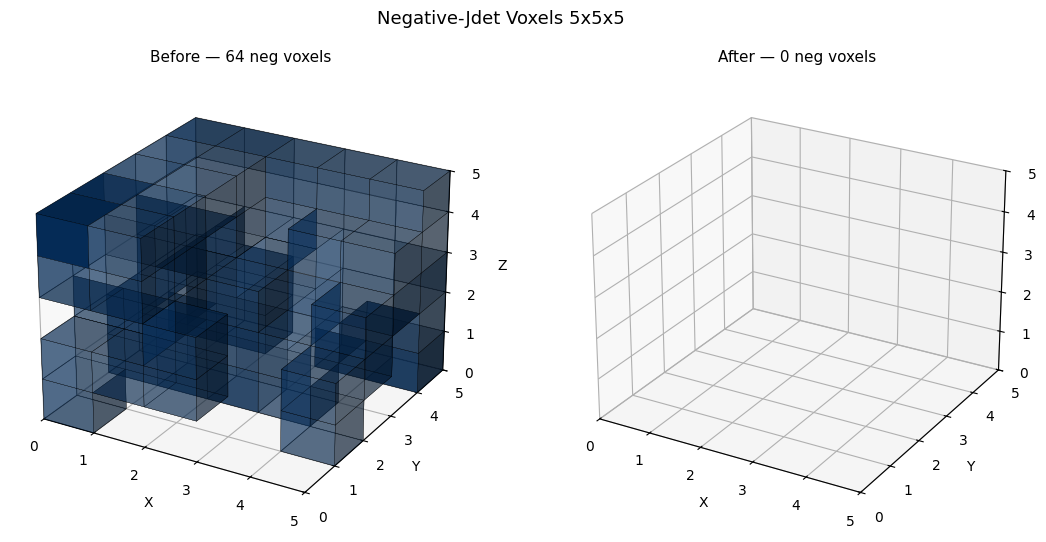

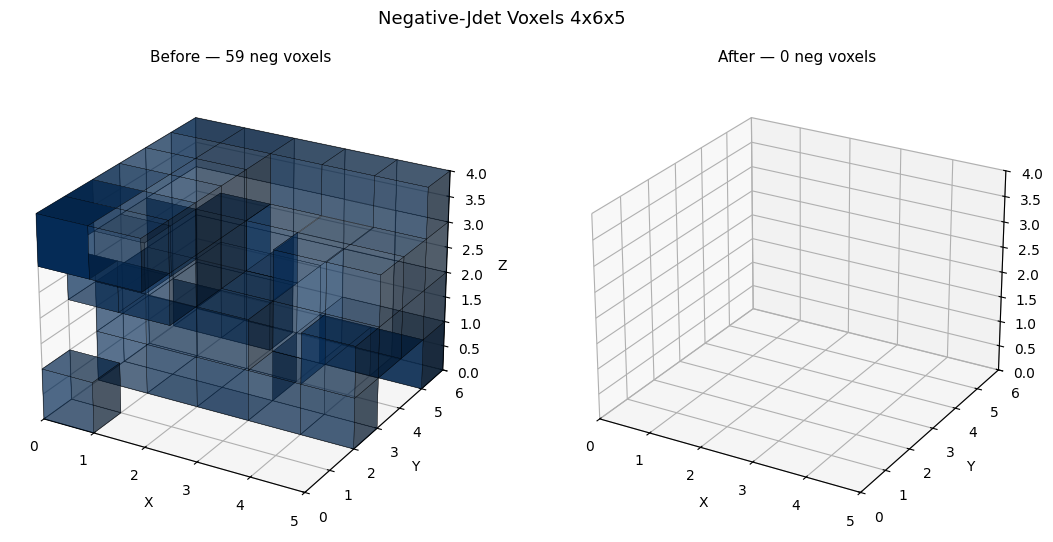

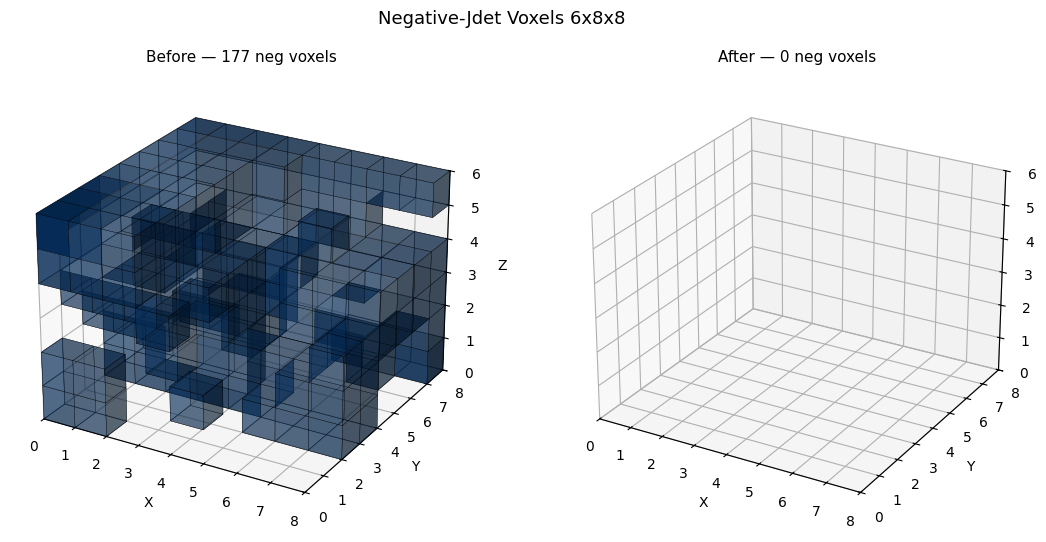

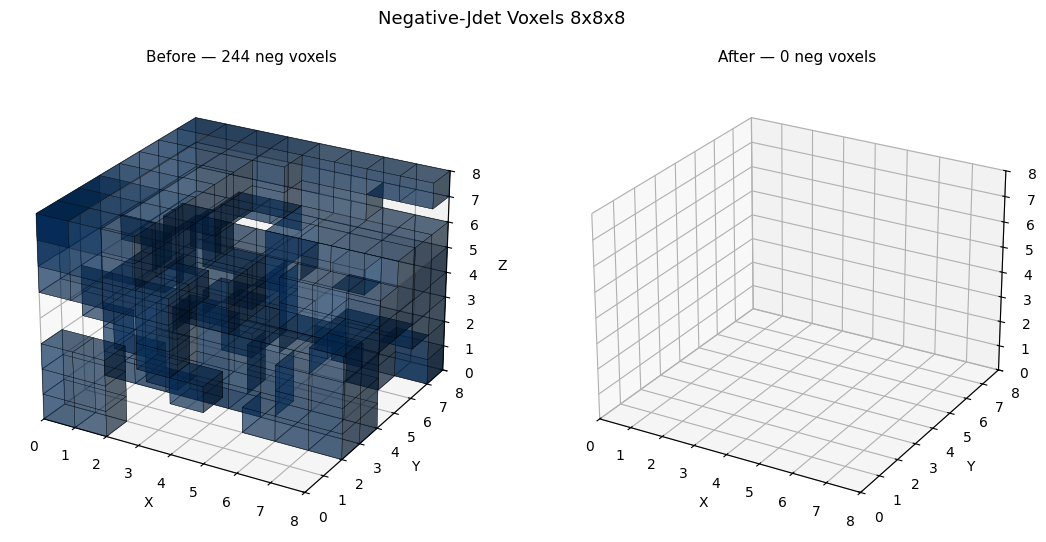

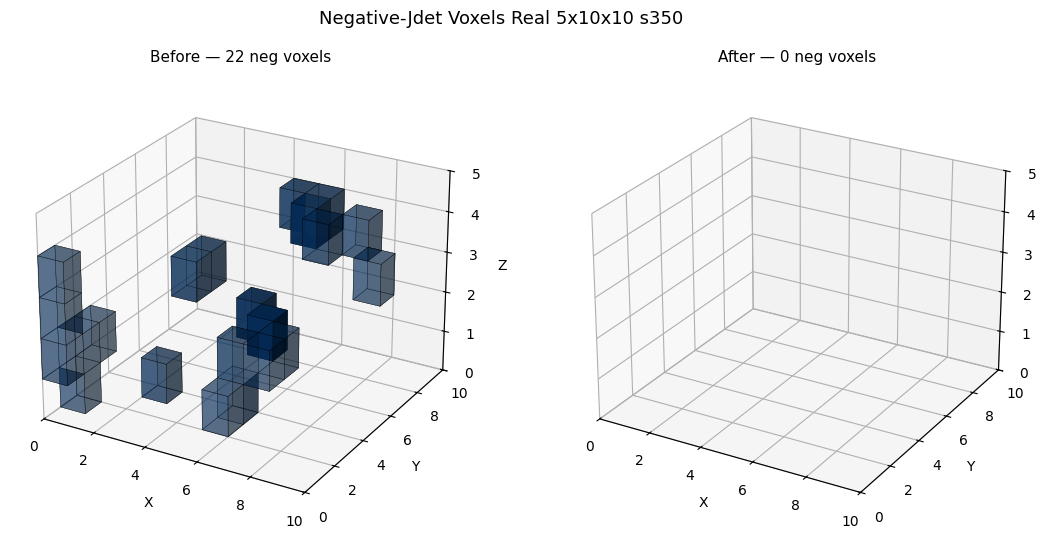

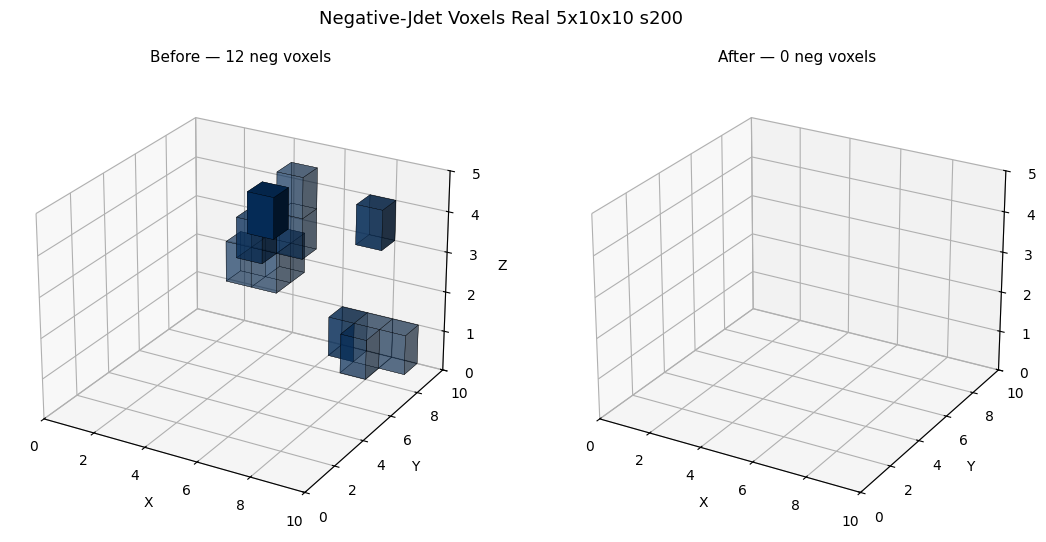

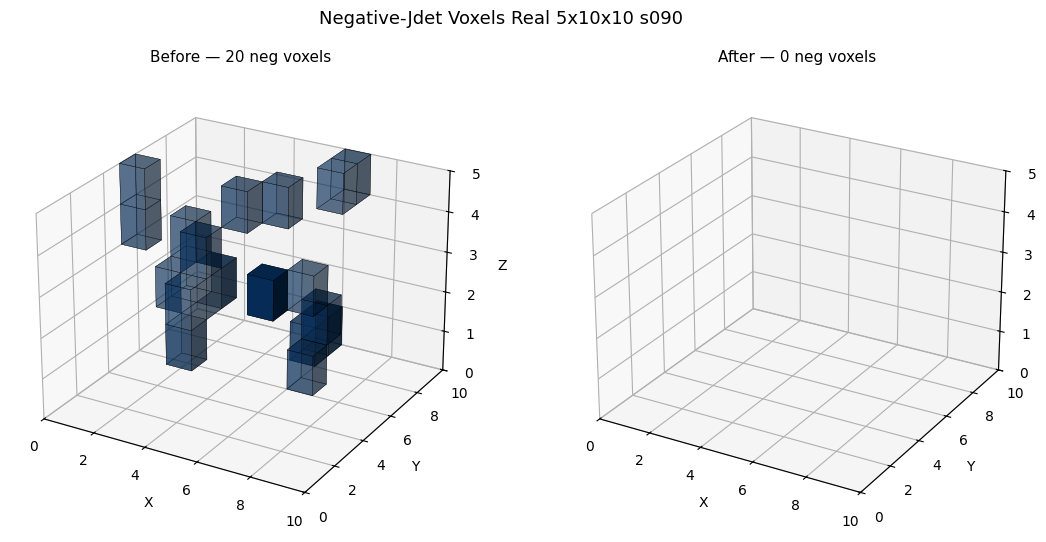

In [6]:
for label, r in results.items():
    if r["n_neg_init"] == 0:
        continue
    plot_neg_voxels_before_after(
        r["jac_init"], r["jac_final"],
        title=f"Negative-Jdet Voxels {label}",
    )
    show_and_save(OUTPUT_DIR)


### 3D Jacobian determinant scatter (before vs after)

All voxels plotted in 3D space.  Large blue dots = negative Jdet (folding);
small pale/transparent dots = positive Jdet (healthy).  After correction
all large blue dots should disappear.

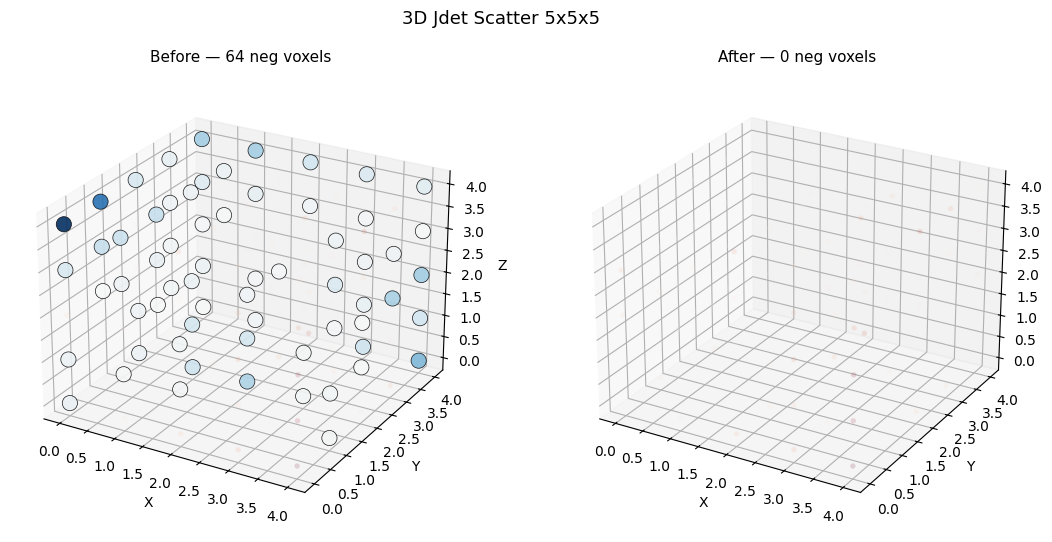

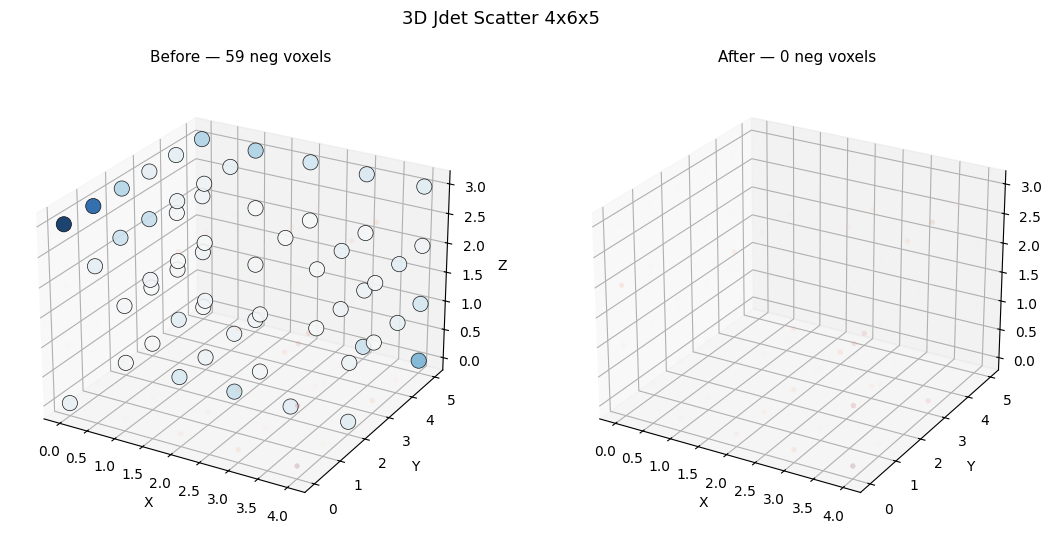

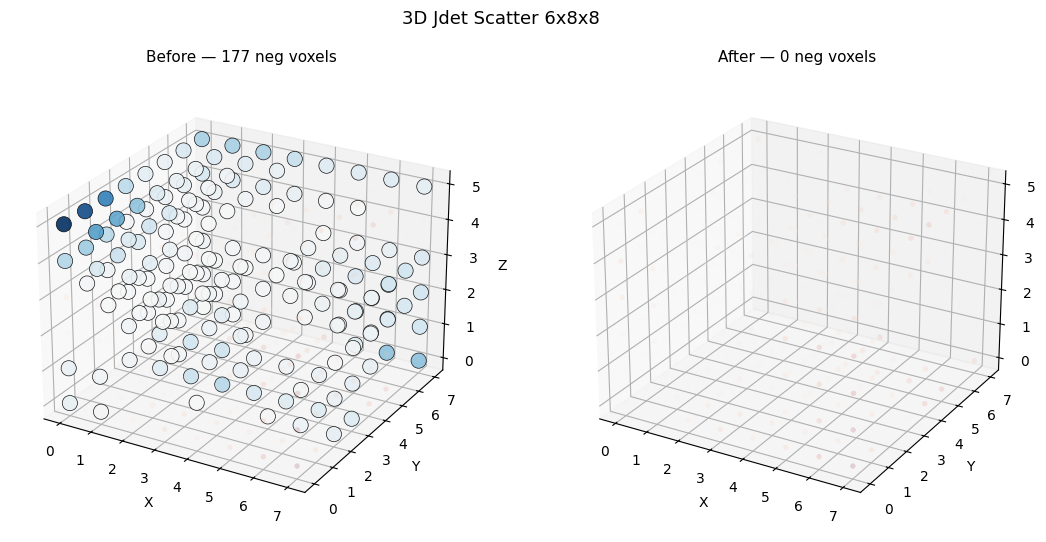

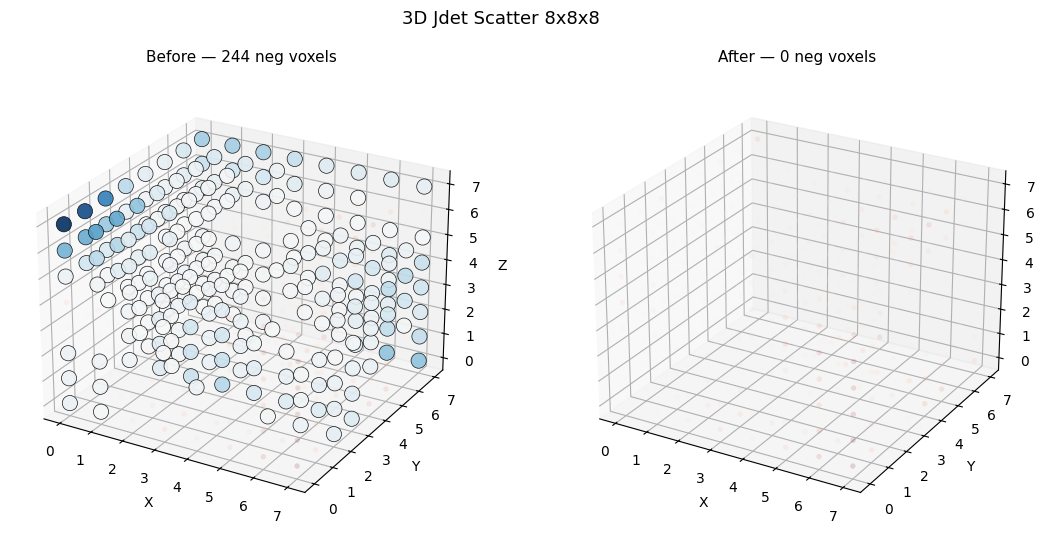

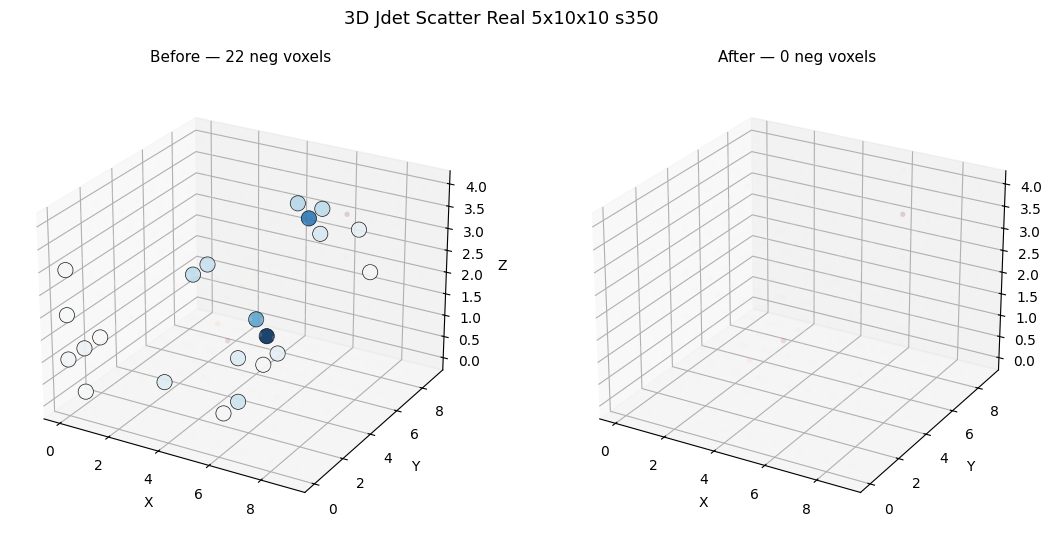

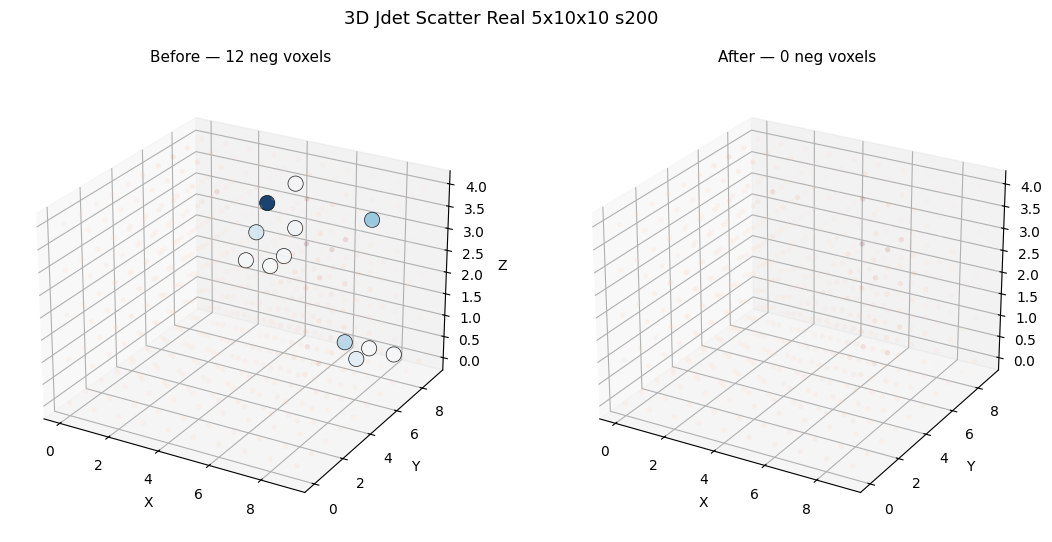

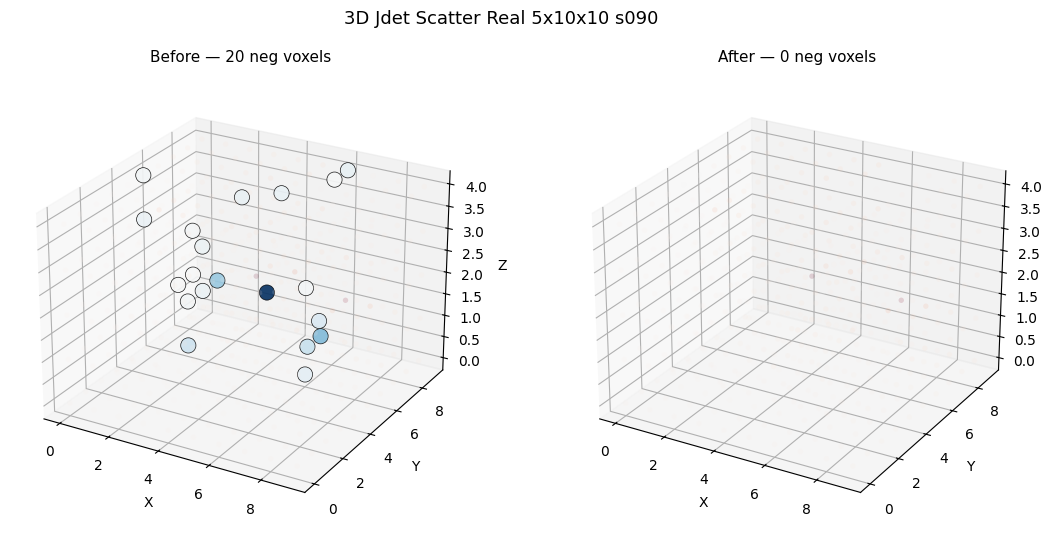

In [7]:
for label, r in results.items():
    if r["n_neg_init"] == 0:
        continue
    plot_jdet_3d_before_after(
        r["jac_init"], r["jac_final"],
        title=f"3D Jdet Scatter {label}",
    )
    show_and_save(OUTPUT_DIR)


### 3D deformation grid (before vs after)

Wireframe of the deformed coordinate grid.  Edge colour reflects the
local Jacobian determinant: blue/thick = negative (folding),
red/thin = positive.

In [8]:
"""
for label, r in results.items():
    if r["n_neg_init"] == 0:
        continue
    plot_grid_before_after_3d(
        r["phi_init"], r["phi"],
        r["jac_init"], r["jac_final"],
        title=f"3D Deformation Grid {label}",
    )
    show_and_save(OUTPUT_DIR)
"""

'\nfor label, r in results.items():\n    if r["n_neg_init"] == 0:\n        continue\n    plot_grid_before_after_3d(\n        r["phi_init"], r["phi"],\n        r["jac_init"], r["jac_final"],\n        title=f"3D Deformation Grid {label}",\n    )\n    plt.show()\n'

### Per-slice Jacobian heatmaps (before vs after)

Classic 2D view: one column per z-slice, top row = before, bottom = after.
Diverging colourmap centred at 0; black contour marks the Jdet = 0 boundary.

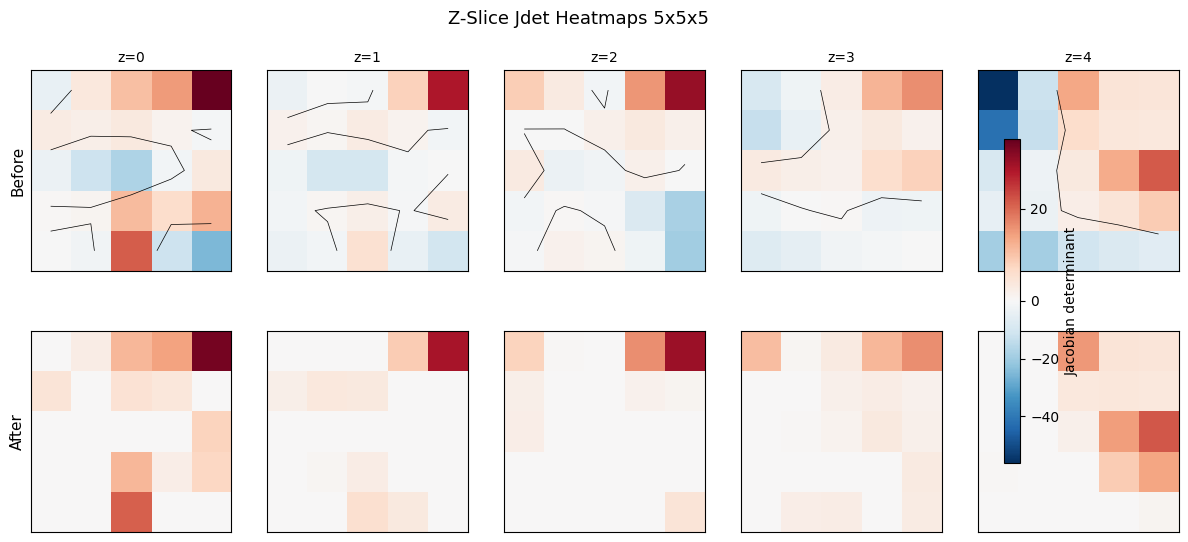

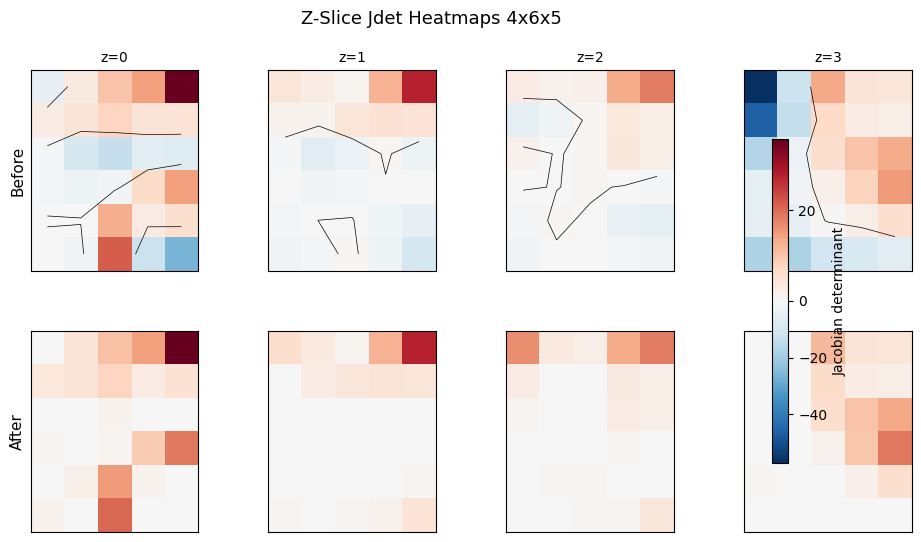

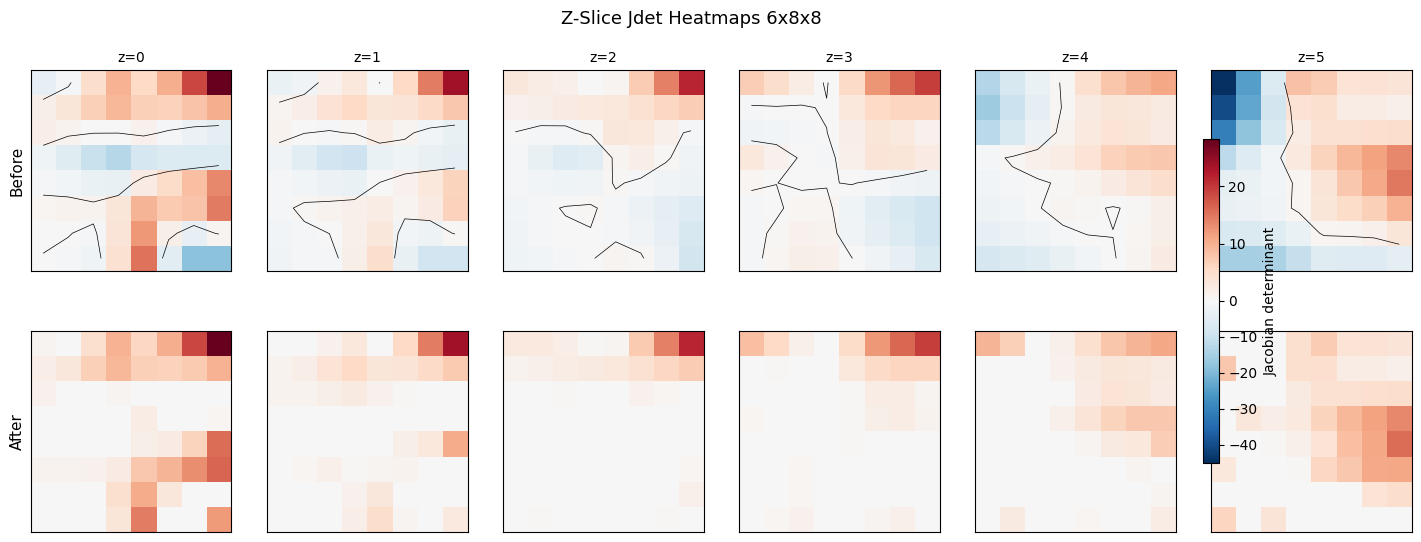

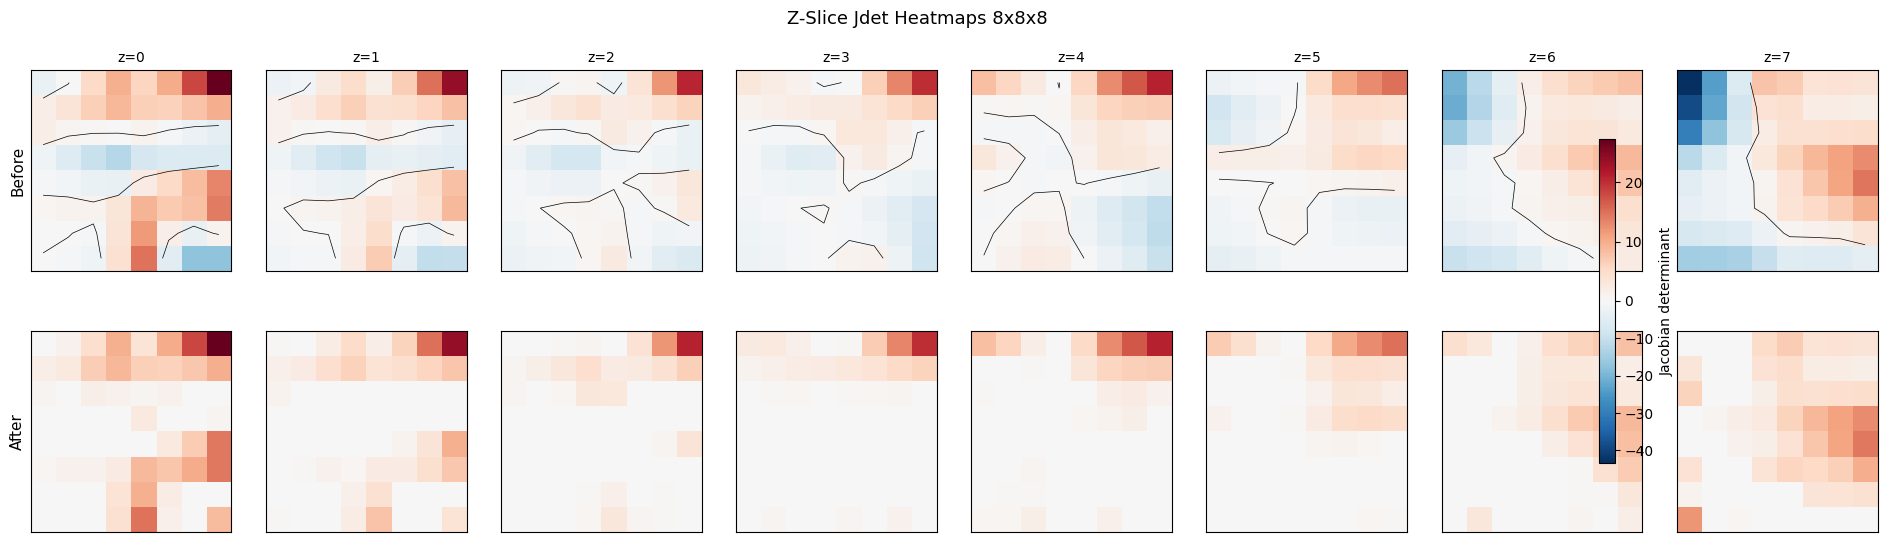

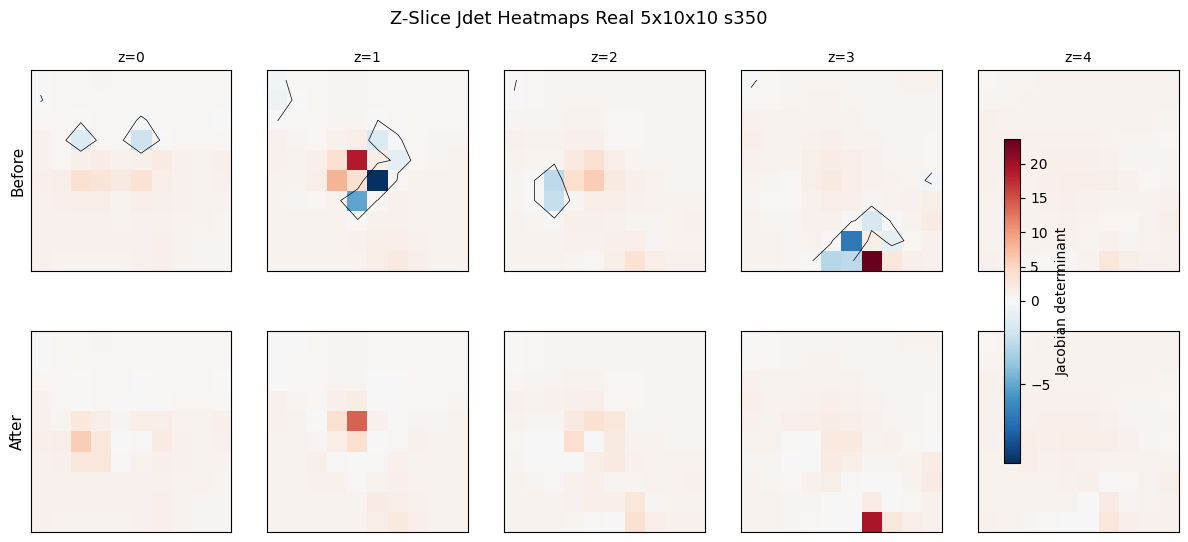

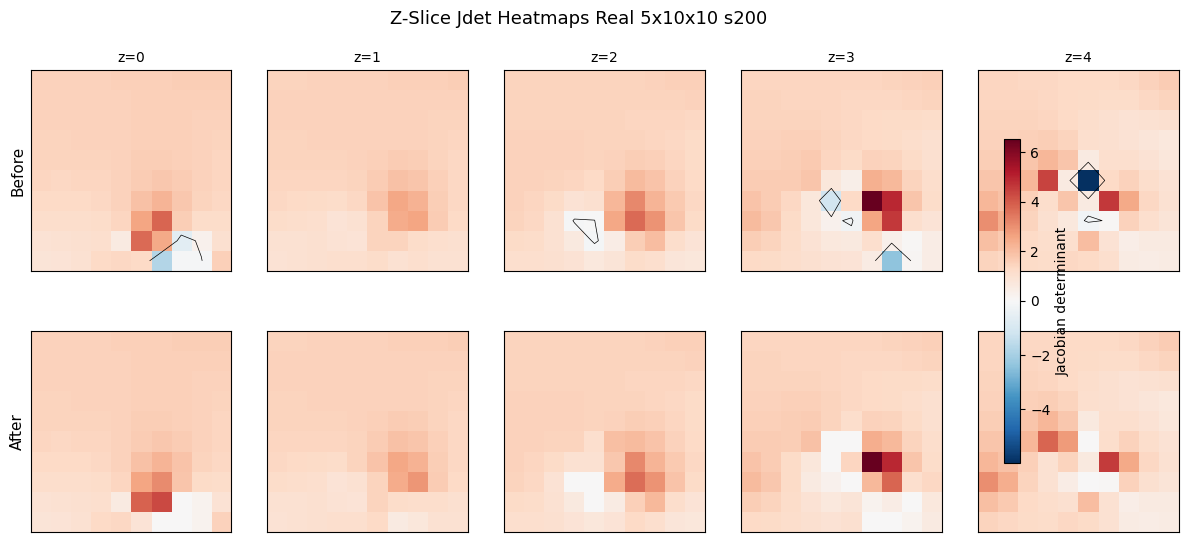

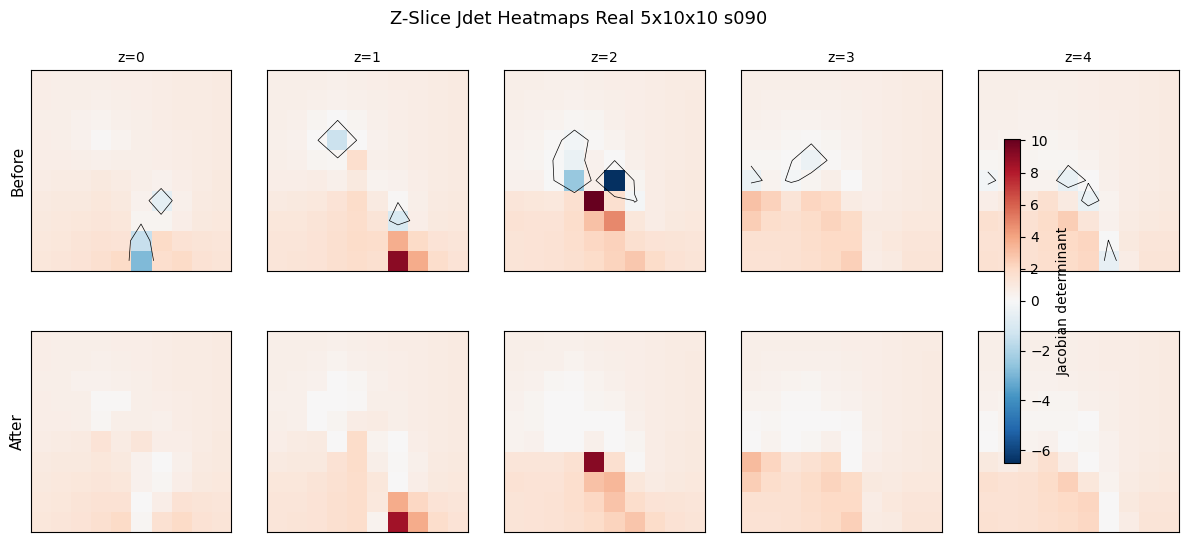

In [9]:
for label, r in results.items():
    if r["n_neg_init"] == 0:
        continue
    plot_jdet_slices(
        r["jac_init"], r["jac_final"],
        title=f"Z-Slice Jdet Heatmaps {label}",
    )
    show_and_save(OUTPUT_DIR)


---
## Metrics summary

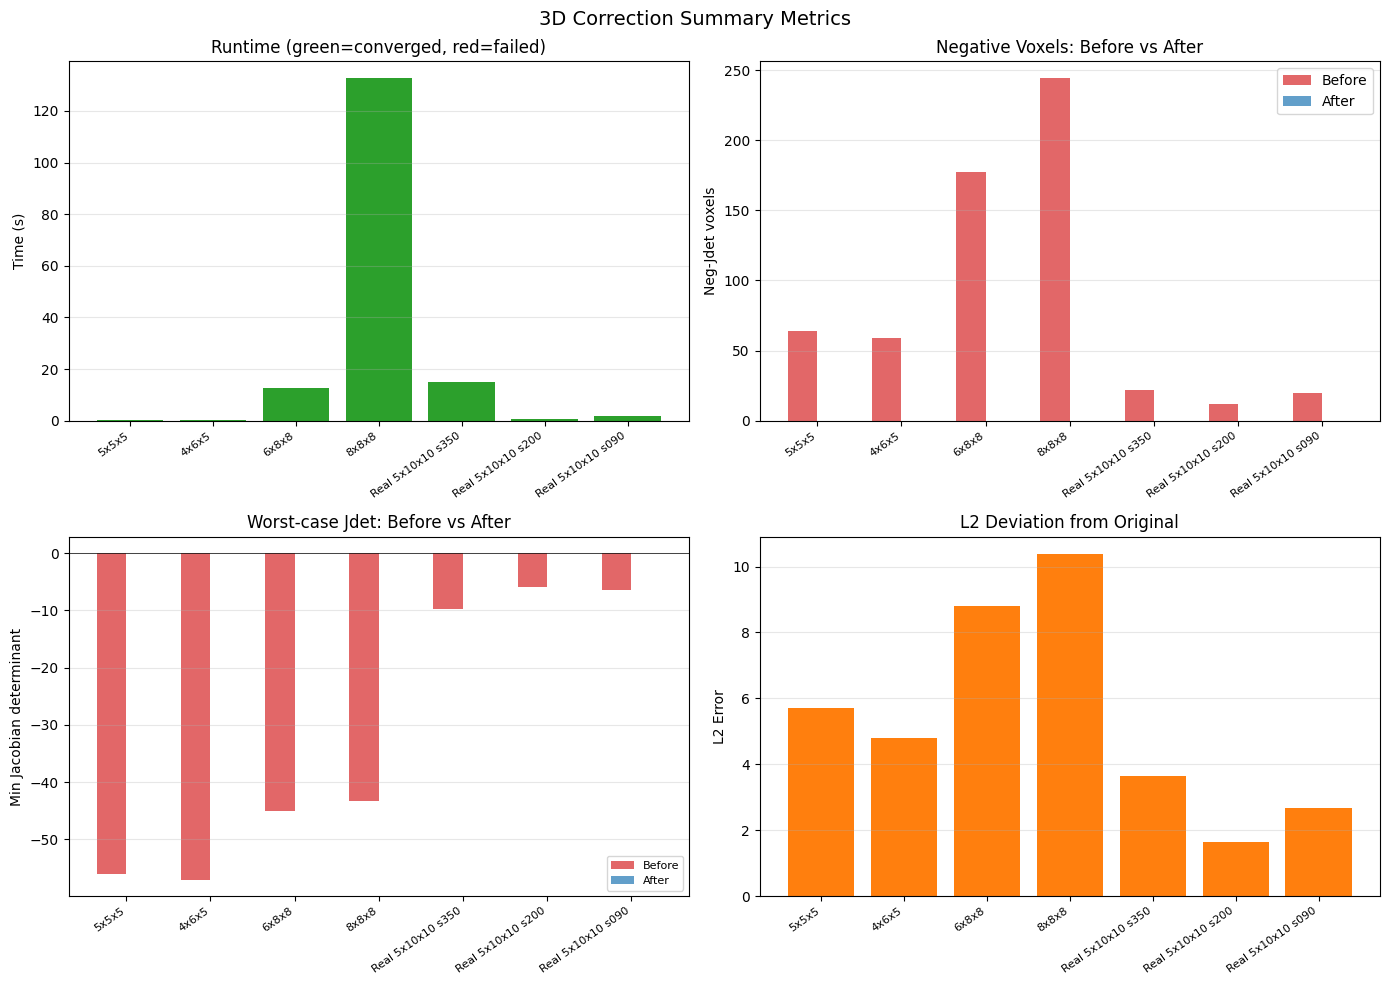

In [10]:
labels = list(results.keys())
times = [results[l]["time"] for l in labels]
negs_init = [results[l]["n_neg_init"] for l in labels]
negs_final = [results[l]["n_neg_final"] for l in labels]
min_init = [results[l]["min_jdet_init"] for l in labels]
min_final = [results[l]["min_jdet"] for l in labels]
l2s = [results[l]["l2_err"] for l in labels]

x = np.arange(len(labels))
w = 0.35

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Runtime
ax = axes[0, 0]
success = [results[l]["n_neg_final"] == 0 for l in labels]
colors = ["tab:green" if s else "tab:red" for s in success]
ax.bar(x, times, color=colors)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=35, ha="right", fontsize=8)
ax.set_ylabel("Time (s)")
ax.set_title("Runtime (green=converged, red=failed)")
ax.grid(True, alpha=0.3, axis="y")

# Neg-Jdet before vs after
ax = axes[0, 1]
ax.bar(x - w/2, negs_init, w, label="Before", color="tab:red", alpha=0.7)
ax.bar(x + w/2, negs_final, w, label="After", color="tab:blue", alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=35, ha="right", fontsize=8)
ax.set_ylabel("Neg-Jdet voxels")
ax.set_title("Negative Voxels: Before vs After")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

# Min Jdet before vs after
ax = axes[1, 0]
ax.bar(x - w/2, min_init, w, label="Before", color="tab:red", alpha=0.7)
ax.bar(x + w/2, min_final, w, label="After", color="tab:blue", alpha=0.7)
ax.axhline(0, color="black", linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=35, ha="right", fontsize=8)
ax.set_ylabel("Min Jacobian determinant")
ax.set_title("Worst-case Jdet: Before vs After")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis="y")

# L2 error
ax = axes[1, 1]
ax.bar(x, l2s, color="tab:orange")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=35, ha="right", fontsize=8)
ax.set_ylabel("L2 Error")
ax.set_title("L2 Deviation from Original")
ax.grid(True, alpha=0.3, axis="y")

plt.suptitle("3D Correction Summary Metrics", fontsize=14)
plt.tight_layout()
show_and_save(OUTPUT_DIR)


## Correction cost analysis

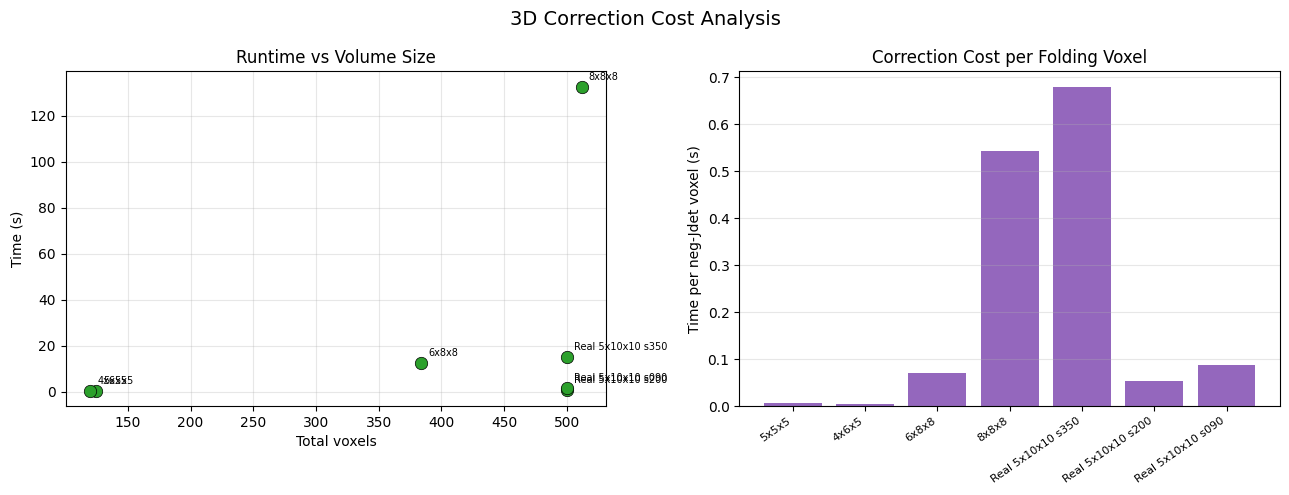

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Runtime vs total voxels
ax = axes[0]
for label, r in results.items():
    D, H, W = r["jac_init"].shape
    total = D * H * W
    c = "tab:green" if r["n_neg_final"] == 0 else "tab:red"
    ax.scatter(total, r["time"], s=80, color=c, zorder=3,
              edgecolors="black", linewidth=0.5)
    ax.annotate(label, (total, r["time"]), fontsize=7,
               textcoords="offset points", xytext=(5, 5))
ax.set_xlabel("Total voxels")
ax.set_ylabel("Time (s)")
ax.set_title("Runtime vs Volume Size")
ax.grid(True, alpha=0.3)

# Time per negative voxel
ax = axes[1]
time_per_neg = [results[l]["time"] / max(results[l]["n_neg_init"], 1)
                for l in labels]
ax.bar(x, time_per_neg, color="tab:purple")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=35, ha="right", fontsize=8)
ax.set_ylabel("Time per neg-Jdet voxel (s)")
ax.set_title("Correction Cost per Folding Voxel")
ax.grid(True, alpha=0.3, axis="y")

plt.suptitle("3D Correction Cost Analysis", fontsize=14)
plt.tight_layout()
show_and_save(OUTPUT_DIR)


## Summary

Key takeaways:
- The `iterative_3d` solver successfully eliminates all negative Jacobian determinants in 3D volumes
- **3D voxel plots** clearly show folding regions (blue blocks) vanishing after correction
- **Deformation grid wireframes** reveal how the solver locally adjusts displacements while preserving the overall deformation structure
- **Per-slice heatmaps** provide a familiar 2D reference for validating the 3D results
- Runtime scales with both volume size and the number of negative voxels

---
## Full-volume negative-Jdet preview (before correction)

Before running the expensive tiled correction, visualise where the folding
sits in the full `(528, 320, 456)` volume. The `plot_neg_voxels_before_after`
voxel renderer would be impractical at this scale, so we do a lightweight 3D
scatter of **only** the negative voxels (coloured blue, matching the other
views). A wireframe of the volume bounds is drawn for reference.

Original full volume: (3,528,320,456)
Downsampled (factor 0.250): (3,132,80,114)  total_voxels=1,203,840
  negative Jdet voxels: 296  (0.025%)
  min Jdet = -11.2018   max Jdet = +14.3700


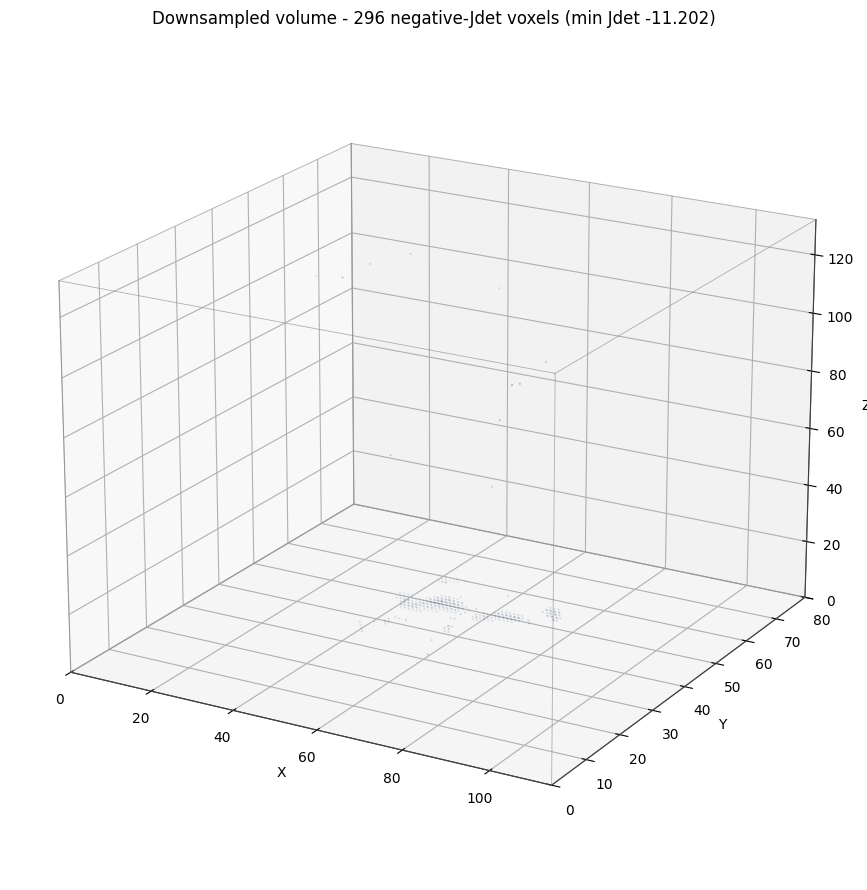

In [12]:
FULL_VOLUME_PATH = "../../../data/corrected_correspondences_count_touching/registered_output/deformation3d.npy"

if os.path.exists(FULL_VOLUME_PATH):
    full_dvf_raw = np.load(FULL_VOLUME_PATH)
    _, Df, Hf, Wf = full_dvf_raw.shape
    ds_shape = (
        max(1, int(round(Df * DOWNSAMPLE_FACTOR))),
        max(1, int(round(Hf * DOWNSAMPLE_FACTOR))),
        max(1, int(round(Wf * DOWNSAMPLE_FACTOR))),
    )
    full_dvf_preview = scale_dvf_3d(full_dvf_raw, ds_shape)
    _, Dv, Hv, Wv = full_dvf_preview.shape

    jac_preview = jacobian_det3D(full_dvf_preview)
    neg_mask = jac_preview <= 0
    n_neg = int(neg_mask.sum())
    total = Dv * Hv * Wv
    print(f"Original full volume: (3,{Df},{Hf},{Wf})")
    print(f"Downsampled (factor {DOWNSAMPLE_FACTOR:.3f}): (3,{Dv},{Hv},{Wv})  total_voxels={total:,}")
    print(f"  negative Jdet voxels: {n_neg:,}  ({100 * n_neg / total:.3f}%)")
    print(f"  min Jdet = {jac_preview.min():+.4f}   max Jdet = {jac_preview.max():+.4f}")

    neg_z, neg_y, neg_x = np.where(neg_mask)
    neg_vals = jac_preview[neg_mask]

    fig = plt.figure(figsize=(11, 9))
    ax = fig.add_subplot(111, projection="3d")

    # Volume bounding box wireframe
    corners = np.array([
        [0, 0, 0], [Wv, 0, 0], [Wv, Hv, 0], [0, Hv, 0],
        [0, 0, Dv], [Wv, 0, Dv], [Wv, Hv, Dv], [0, Hv, Dv],
    ])
    edges = [
        (0, 1), (1, 2), (2, 3), (3, 0),
        (4, 5), (5, 6), (6, 7), (7, 4),
        (0, 4), (1, 5), (2, 6), (3, 7),
    ]
    for i, j in edges:
        ax.plot(
            [corners[i, 0], corners[j, 0]],
            [corners[i, 1], corners[j, 1]],
            [corners[i, 2], corners[j, 2]],
            color="gray", linewidth=0.6, alpha=0.6,
        )

    if n_neg > 0:
        worst = min(float(neg_vals.min()), -1e-10)
        alpha = np.clip(0.25 + 0.65 * np.abs(neg_vals) / abs(worst), 0.25, 0.9)
        rgba = np.zeros((len(neg_vals), 4))
        rgba[:, 0] = 0.02
        rgba[:, 1] = 0.19
        rgba[:, 2] = 0.38
        rgba[:, 3] = alpha
        ax.scatter(
            neg_x, neg_y, neg_z,
            c=rgba, s=2.5, edgecolors="none", depthshade=True,
        )

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.set_xlim(0, Wv)
    ax.set_ylim(0, Hv)
    ax.set_zlim(0, Dv)
    ax.set_title(
        f"Downsampled volume - {n_neg:,} negative-Jdet voxels "
        f"(min Jdet {jac_preview.min():+.3f})",
        fontsize=12,
    )
    ax.view_init(elev=20, azim=-60)
    plt.tight_layout()
    show_and_save(OUTPUT_DIR)

    del full_dvf_raw, full_dvf_preview, jac_preview, neg_mask
else:
    print(f"Full volume file not found: {FULL_VOLUME_PATH}")


---
## Half-resolution real-data benchmark (serial)

Loads the full Elastix-registered deformation field
(`data/corrected_correspondences_count_touching/registered_output/deformation3d.npy`),
**downsamples it by a factor of two** on every axis via `scale_dvf_3d`
(trilinear interpolation with proportional displacement rescaling),
then runs plain serial `iterative_3d` on the resulting half-resolution
field.

Running at half resolution drops the variable count ~8x and shrinks the
folding blobs to a scale where the stock serial solver can chew through
them without the OOM / thrashing issues of the full volume. Results are
stored under the label `"Real half-res"`.

In [13]:
# Diagnose component sizes BEFORE calling iterative_3d.
# The solver grinds when any connected neg-Jdet component has a large
# bounding box (SLSQP Hessian is dense, O(N^2) memory in window voxels).
from scipy.ndimage import label, find_objects

if "ds_dvf" not in globals():
    full_dvf_raw = np.load(FULL_VOLUME_PATH)
    _, Df, Hf, Wf = full_dvf_raw.shape
    ds_shape = (
        max(1, int(round(Df * DOWNSAMPLE_FACTOR))),
        max(1, int(round(Hf * DOWNSAMPLE_FACTOR))),
        max(1, int(round(Wf * DOWNSAMPLE_FACTOR))),
    )
    ds_dvf = scale_dvf_3d(full_dvf_raw, ds_shape)
    del full_dvf_raw

jac_ds = jacobian_det3D(ds_dvf)
neg_mask = jac_ds <= 0
labels_arr, n_comp = label(neg_mask, structure=np.ones((3, 3, 3)))
slices = find_objects(labels_arr)

print(f"grid: {jac_ds.shape}  neg voxels: {int(neg_mask.sum())}  components: {n_comp}")
sizes = []
for idx, slc in enumerate(slices, start=1):
    if slc is None:
        continue
    sz = slc[0].stop - slc[0].start
    sy = slc[1].stop - slc[1].start
    sx = slc[2].stop - slc[2].start
    wz, wy, wx = sz + 2, sy + 2, sx + 2
    n_vars = 3 * wz * wy * wx
    sizes.append((n_vars, wz, wy, wx, idx))

sizes.sort(reverse=True)
print("Top 10 biggest components (bbox + 1-voxel border):")
print("  rank      n_vars    window (zyx)")
for r, (nv, wz, wy, wx, cid) in enumerate(sizes[:10], start=1):
    print(f"  {r:>4d}  {nv:>10d}   {wz:>3d}x{wy:>3d}x{wx:>3d}")

big = sum(1 for s in sizes if s[0] > 3000)
print()
print(f"{big} components have > 3000 SLSQP vars -- those are the slow ones.")


grid: (132, 80, 114)  neg voxels: 296  components: 30
Top 10 biggest components (bbox + 1-voxel border):
  rank      n_vars    window (zyx)
     1        3570     7x 10x 17
     2        1008     4x  7x 12
     3         840     5x  7x  8
     4         525     5x  5x  7
     5         240     5x  4x  4
     6         180     3x  5x  4
     7         144     4x  4x  3
     8         144     3x  4x  4
     9         144     3x  4x  4
    10         144     3x  4x  4

1 components have > 3000 SLSQP vars -- those are the slow ones.


In [ ]:
RUN_DOWNSAMPLED = True

FULL_VOLUME_PATH = "../../../data/corrected_correspondences_count_touching/registered_output/deformation3d.npy"

if RUN_DOWNSAMPLED and os.path.exists(FULL_VOLUME_PATH):
    full_dvf = np.load(FULL_VOLUME_PATH)
    _, Dv, Hv, Wv = full_dvf.shape
    new_shape = (
        max(1, int(round(Dv * DOWNSAMPLE_FACTOR))),
        max(1, int(round(Hv * DOWNSAMPLE_FACTOR))),
        max(1, int(round(Wv * DOWNSAMPLE_FACTOR))),
    )
    print(f"Original full volume: {full_dvf.shape}", flush=True)
    print(f"Downsampling by {DOWNSAMPLE_FACTOR} -> (3, {new_shape[0]}, "
          f"{new_shape[1]}, {new_shape[2]})", flush=True)

    ds_dvf = scale_dvf_3d(full_dvf, new_shape)

    jac_init = jacobian_det3D(ds_dvf)
    init_neg = int((jac_init <= 0).sum())
    init_min = float(jac_init.min())
    print(f"  after downsample: neg voxels = {init_neg}  "
          f"min Jdet = {init_min:+.4f}", flush=True)
    print(f"  STARTING TOTAL NEG VOXELS: {init_neg}", flush=True)

    print("Running serial iterative_3d ...", flush=True)
    t0 = time.time()
    phi = iterative_3d(
        ds_dvf,
        verbose=2,
        max_per_index_iter=50,
        max_minimize_iter=10,
        max_window=(7, 7, 7),
        max_iterations=200,
    )
    elapsed = time.time() - t0

    jac_final = jacobian_det3D(phi)
    n_neg_final = int((jac_final <= 0).sum())
    min_jdet_final = float(jac_final.min())
    l2_err = float(np.linalg.norm(phi - ds_dvf))

    results["Real half-res"] = {
        "phi": phi,
        "phi_init": ds_dvf,
        "jac_init": jac_init,
        "jac_final": jac_final,
        "time": elapsed,
        "n_neg_init": init_neg,
        "n_neg_final": n_neg_final,
        "min_jdet_init": init_min,
        "min_jdet": min_jdet_final,
        "l2_err": l2_err,
    }

    status = "OK" if n_neg_final == 0 else "PARTIAL"
    print(f"Half-res serial: time={elapsed:.1f}s", flush=True)
    print(
        f"  STARTED WITH {init_neg} neg voxels -> FINAL {n_neg_final} neg voxels "
        f"(removed {init_neg - n_neg_final})",
        flush=True,
    )
    print(
        f"  min_jdet={min_jdet_final:+.6f}  L2={l2_err:.4f}  [{status}]",
        flush=True,
    )
elif not RUN_DOWNSAMPLED:
    print("Skipped half-res run (set RUN_DOWNSAMPLED = True to enable).")
else:
    print(f"Full volume file not found: {FULL_VOLUME_PATH}")


In [ ]:
# Visualize the downsampled deformation field (before vs after correction)
if "Real half-res" in results:
    r = results["Real half-res"]

    plot_jdet_3d_before_after(
        r["jac_init"], r["jac_final"],
        title="Half-res full volume - Jdet scatter",
    )
    show_and_save(OUTPUT_DIR)

    plot_jdet_slices(
        r["jac_init"], r["jac_final"],
        title="Half-res full volume - z-slice Jdet heatmaps",
    )
    show_and_save(OUTPUT_DIR)

    plot_neg_voxels_before_after(
        r["jac_init"], r["jac_final"],
        title="Half-res full volume - negative Jdet voxels",
    )
    show_and_save(OUTPUT_DIR)


In [ ]:
# --- Save results ---
if 'results' in dir() and isinstance(results, dict) and results:
    rows, cols = results_to_rows(results)
    save_results_csv(rows, cols, OUTPUT_DIR)
    summary = log_run_footer(summary, results)
    save_summary_json(summary, OUTPUT_DIR)
elif 'mag_results' in dir():
    rows, cols = results_to_rows(mag_results)
    save_results_csv(rows, cols, OUTPUT_DIR, name='results_magnitude')
    if 'density_results' in dir():
        rows2, cols2 = results_to_rows(density_results)
        save_results_csv(rows2, cols2, OUTPUT_DIR, name='results_density')
    combined = {**mag_results, **density_results} if 'density_results' in dir() else mag_results
    summary = log_run_footer(summary, combined)
    save_summary_json(summary, OUTPUT_DIR)
else:
    save_summary_json(summary, OUTPUT_DIR)
    print('No results dict found; saved summary only.')
